In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prince7489/online-learning-platform-usage-dataset/online_learning_platform_usage_dataset.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'  # or 'iframe_connected'
pio.renderers.default = 'iframe_connected'
import warnings
warnings.filterwarnings("ignore")

# Project
## Online Platform Usage Analysis 

In [3]:
df=pd.read_csv(r"/kaggle/input/datasets/prince7489/online-learning-platform-usage-dataset/online_learning_platform_usage_dataset.csv")

# Data Info 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  420 non-null    int64 
 1   age_group                420 non-null    object
 2   role                     420 non-null    object
 3   primary_platform         420 non-null    object
 4   learning_device          420 non-null    object
 5   hours_per_week           420 non-null    int64 
 6   learning_purpose         420 non-null    object
 7   content_type_preference  420 non-null    object
 8   completion_rate_percent  420 non-null    int64 
 9   satisfaction_score       420 non-null    int64 
dtypes: int64(4), object(6)
memory usage: 32.9+ KB


In [5]:
df.describe()

,user_id,hours_per_week,completion_rate_percent,satisfaction_score
count,420.000000,420.000000,420.000000,420.000000
mean,210.500000,10.476190,53.935714,5.228571
std,121.387808,5.708253,26.638357,2.814918
min,1.000000,1.000000,10.000000,1.000000
25%,105.750000,5.750000,30.000000,3.000000
50%,210.500000,11.000000,54.000000,5.000000
75%,315.250000,15.000000,77.250000,8.000000
max,420.000000,20.000000,100.000000,10.000000


In [6]:
df.head()

,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score
0,1,35-44,Working Professional,edX,Laptop,10,Career Growth,Text,34,5
1,2,45+,Other,edX,Mobile,12,Career Growth,Text,17,3
2,3,25-34,Freelancer,Skillshare,Desktop,2,Academic,Text,67,9
3,4,45+,Working Professional,Udemy,Mobile,3,Career Growth,Mixed,25,5
4,5,45+,Working Professional,Khan Academy,Mobile,10,Hobby,Video,81,5


In [7]:
df.shape

(420, 10)

# Data Cleaning & Handling

In [8]:
df.isna().sum()

user_id                    0
age_group                  0
role                       0
primary_platform           0
learning_device            0
hours_per_week             0
learning_purpose           0
content_type_preference    0
completion_rate_percent    0
satisfaction_score         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# EDA & Visualization

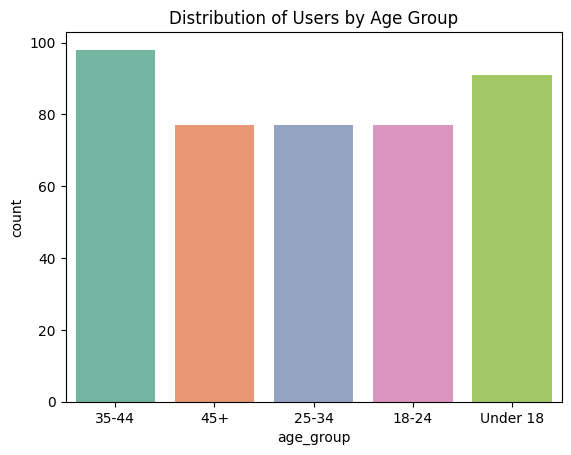

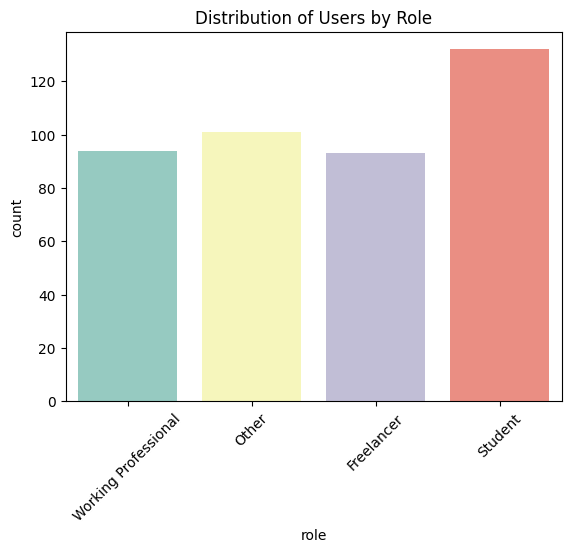

In [10]:
sns.countplot(x="age_group", data=df, palette="Set2")
plt.title("Distribution of Users by Age Group")
plt.show()

sns.countplot(x="role", data=df, palette="Set3")
plt.title("Distribution of Users by Role")
plt.xticks(rotation=45)
plt.show()


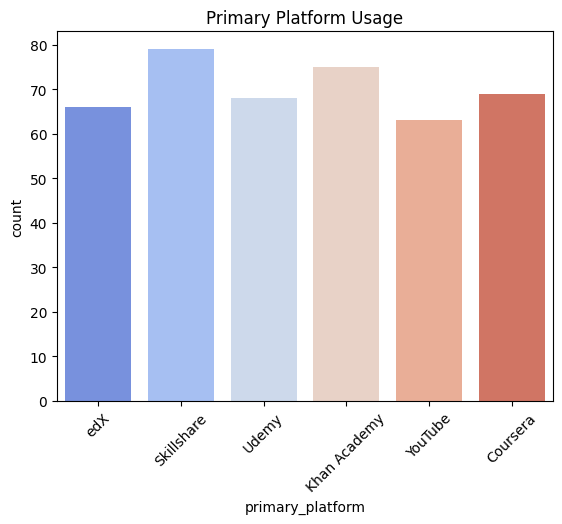

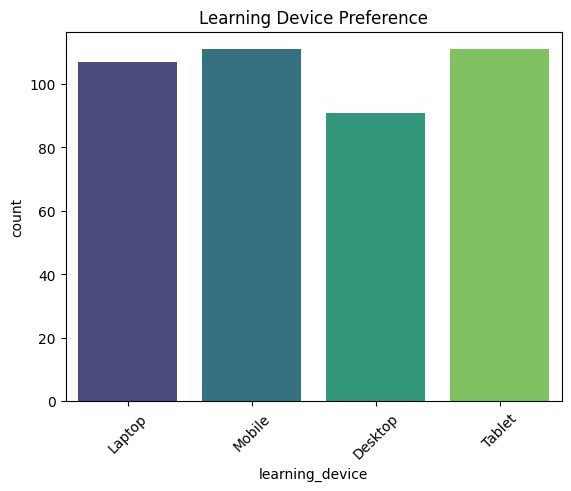

In [11]:
sns.countplot(x="primary_platform", data=df, palette="coolwarm")
plt.title("Primary Platform Usage")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x="learning_device", data=df, palette="viridis")
plt.title("Learning Device Preference")
plt.xticks(rotation=45)
plt.show()


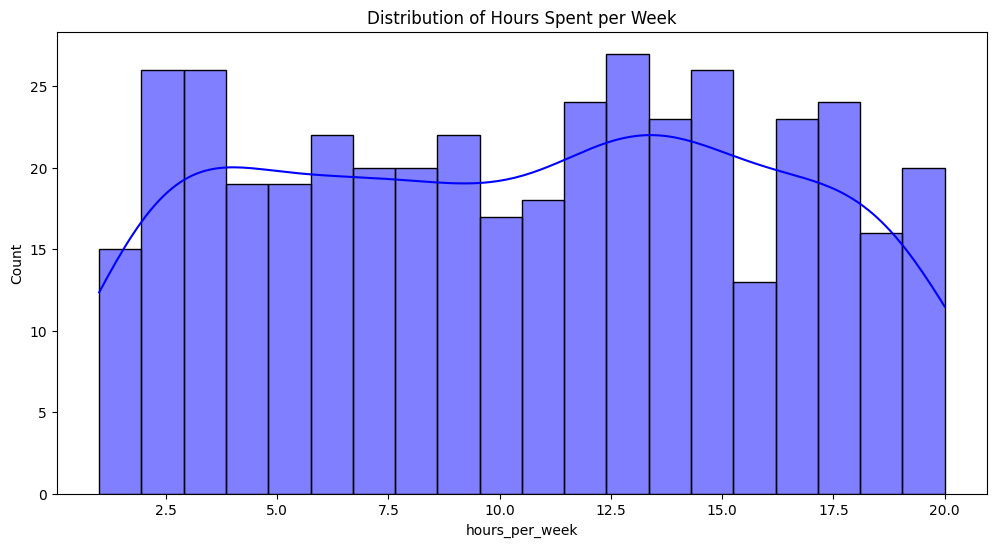

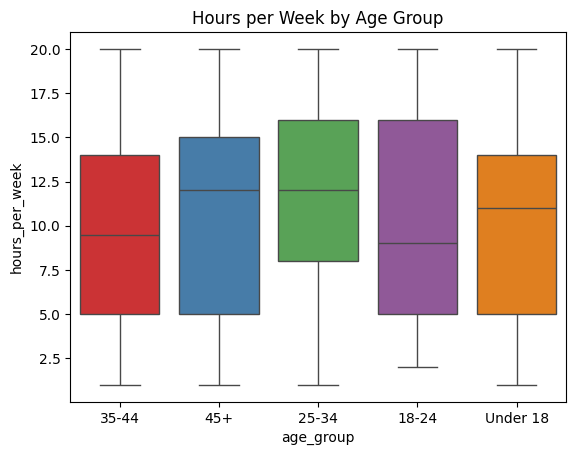

In [12]:
plt.figure(figsize=(12,6))
sns.histplot(df["hours_per_week"], bins=20, kde=True, color="blue")
plt.title("Distribution of Hours Spent per Week")
plt.show()

sns.boxplot(x="age_group", y="hours_per_week", data=df, palette="Set1")
plt.title("Hours per Week by Age Group")
plt.show()


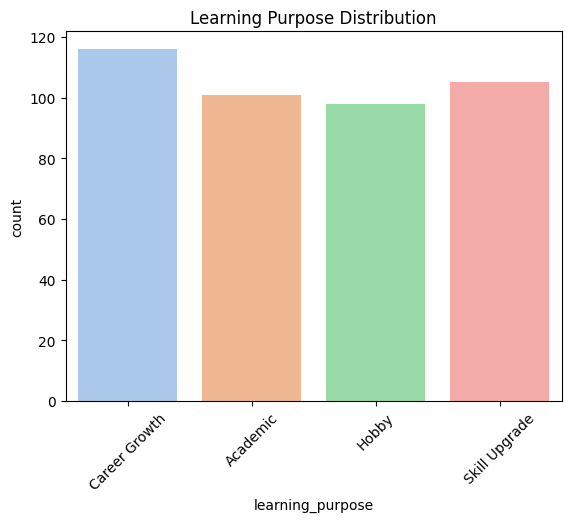

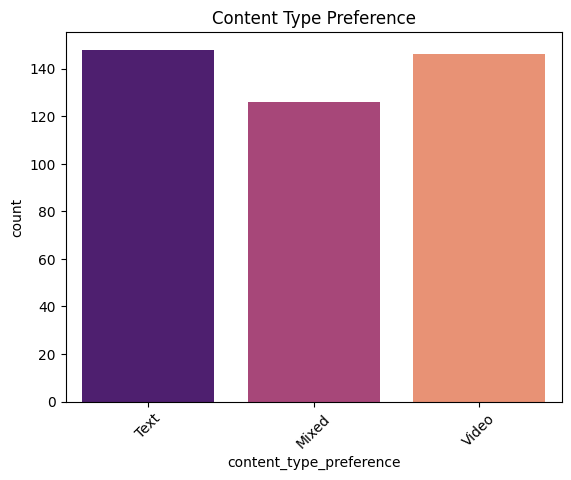

In [13]:
sns.countplot(x="learning_purpose", data=df, palette="pastel")
plt.title("Learning Purpose Distribution")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x="content_type_preference", data=df, palette="magma")
plt.title("Content Type Preference")
plt.xticks(rotation=45)
plt.show()


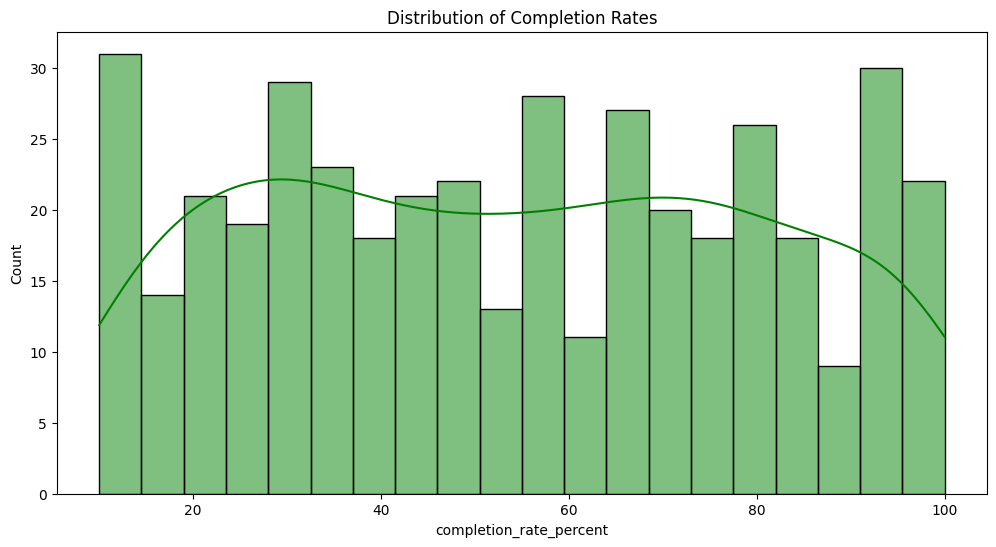

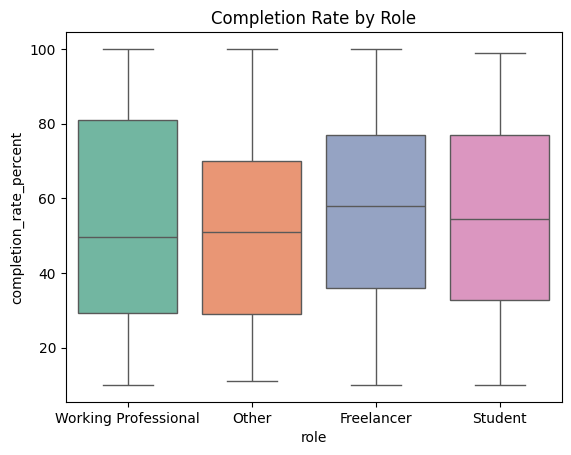

In [14]:
plt.figure(figsize=(12,6))
sns.histplot(df["completion_rate_percent"], bins=20, kde=True, color="green")
plt.title("Distribution of Completion Rates")
plt.show()

sns.boxplot(x="role", y="completion_rate_percent", data=df, palette="Set2")
plt.title("Completion Rate by Role")
plt.show()


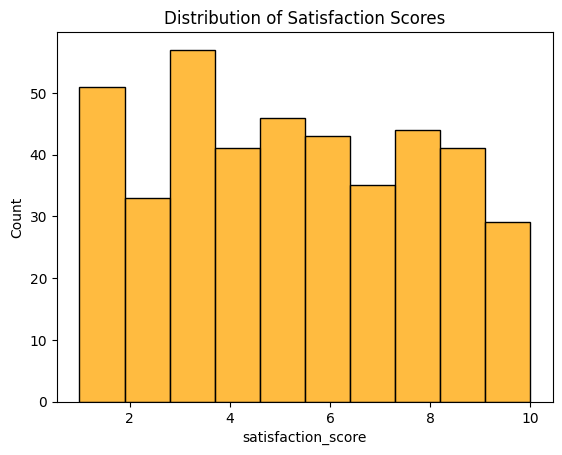

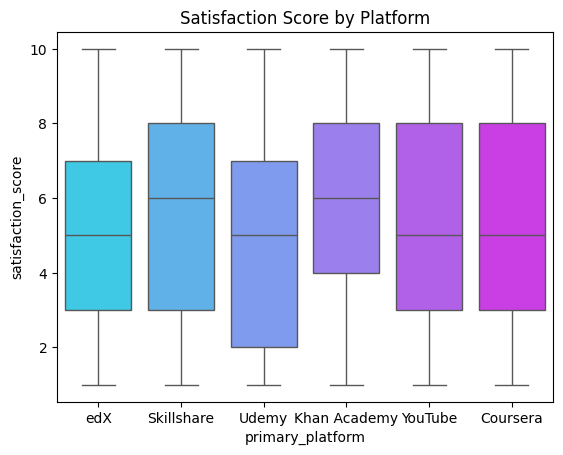

In [15]:
sns.histplot(df["satisfaction_score"], bins=10, kde=False, color="orange")
plt.title("Distribution of Satisfaction Scores")
plt.show()

sns.boxplot(x="primary_platform", y="satisfaction_score", data=df, palette="cool")
plt.title("Satisfaction Score by Platform")
plt.show()


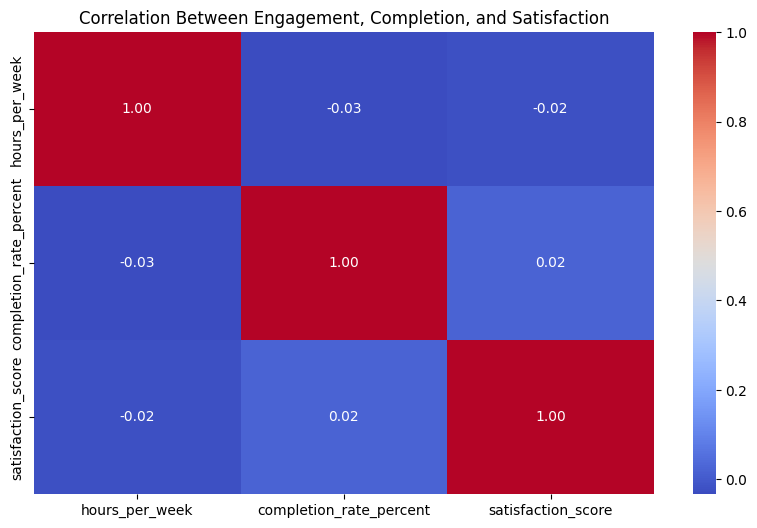

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df[["hours_per_week","completion_rate_percent","satisfaction_score"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Engagement, Completion, and Satisfaction")
plt.show()
